In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## 01. Importing Necessary Libraries

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

## 02. Loading the Datasets

In [3]:
# Load the datasets
train_path = "train.csv"
test_path = "test.csv"
sample_submission = pd.read_csv("sample_submission.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

## 03. Checking the Data

In [4]:
train_df.head()

,id,emotional_charge_2,groove_efficiency_1,beat_frequency_1,organic_texture_2,composition_label_0,harmonic_scale_1,intensity_index_0,duration_ms_0,album_name_length,...,time_signature_0,duration_ms_1,harmonic_scale_0,time_signature_2,rhythmic_cohesion_2,emotional_resonance_0,harmonic_scale_2,intensity_index_2,instrumental_density_0,target
0,76339,0.482850,1.169231,80.018,0.0201,Country Stuff (feat. Jake Owen),1.0,0.789,154586.0,NaN,...,4.0,161853.0,7.0,4.0,NaN,0.607,7.0,0.7250,0.000000,74
1,80006,0.267862,1.321321,147.966,0.3340,Solitude,6.0,0.715,46874.0,15.0,...,4.0,155619.0,1.0,4.0,0.843,0.783,4.0,NaN,0.043200,2
2,83501,0.242606,1.285319,142.980,0.1110,BDFFRNT (Saved from Conformity),4.0,NaN,264665.0,7.0,...,4.0,209378.0,6.0,4.0,NaN,0.211,10.0,0.6020,0.000000,35
3,81530,0.426400,1.279435,123.063,0.1960,Headlights (feat. Ilsey),5.0,0.685,209208.0,5.0,...,4.0,219043.0,11.0,4.0,0.702,0.369,NaN,0.8200,0.000335,70
4,60534,0.000000,0.974906,132.722,0.0811,Afraid,6.0,0.856,215346.0,5.0,...,4.0,258893.0,1.0,0.0,0.000,0.631,1.0,0.0221,0.000000,78


In [5]:
test_df.head()

,id,emotional_charge_2,groove_efficiency_1,beat_frequency_1,organic_texture_2,composition_label_0,harmonic_scale_1,intensity_index_0,duration_ms_0,album_name_length,...,emotional_resonance_2,time_signature_0,duration_ms_1,harmonic_scale_0,time_signature_2,rhythmic_cohesion_2,emotional_resonance_0,harmonic_scale_2,intensity_index_2,instrumental_density_0
0,25174,0.600480,1.543590,124.008,0.0729,Dr.Q,1.0,0.763,23032.0,4.0,...,0.834,4.0,253987.0,4.0,4.0,0.604,0.2050,0.0,0.720,0.165000
1,38453,NaN,0.722420,129.942,0.0105,Start A Party,11.0,0.801,215466.0,20.0,...,0.216,4.0,267626.0,5.0,4.0,0.881,0.2610,1.0,0.496,0.000000
2,29013,0.461916,0.757962,83.000,0.2700,Sombras - Live,2.0,0.561,252261.0,44.0,...,0.546,4.0,226626.0,0.0,4.0,0.555,0.0555,0.0,0.846,0.002760
3,57463,0.144236,0.923977,183.991,0.1210,Tennis Court,2.0,NaN,198907.0,23.0,...,0.337,4.0,234286.0,0.0,4.0,0.674,0.4040,7.0,0.428,0.000194
4,51264,0.629832,1.473795,201.277,0.0610,La Cumbia Del Lazo,10.0,0.716,158720.0,NaN,...,0.966,4.0,188520.0,8.0,4.0,0.511,0.9620,10.0,0.652,0.000115


In [6]:
train_df.shape

(61609, 62)

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61609 entries, 0 to 61608
Data columns (total 62 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          61609 non-null  int64  
 1   emotional_charge_2          59167 non-null  float64
 2   groove_efficiency_1         61429 non-null  float64
 3   beat_frequency_1            61223 non-null  float64
 4   organic_texture_2           61226 non-null  float64
 5   composition_label_0         58660 non-null  object 
 6   harmonic_scale_1            58304 non-null  float64
 7   intensity_index_0           55638 non-null  float64
 8   duration_ms_0               60320 non-null  float64
 9   album_name_length           52015 non-null  float64
 10  beat_frequency_0            51878 non-null  float64
 11  beat_frequency_2            59843 non-null  float64
 12  artist_count                58348 non-null  float64
 13  composition_label_1         601

In [8]:
train_df.describe()

,id,emotional_charge_2,groove_efficiency_1,beat_frequency_1,organic_texture_2,harmonic_scale_1,intensity_index_0,duration_ms_0,album_name_length,beat_frequency_0,...,time_signature_0,duration_ms_1,harmonic_scale_0,time_signature_2,rhythmic_cohesion_2,emotional_resonance_0,harmonic_scale_2,intensity_index_2,instrumental_density_0,target
count,61609.000000,59167.000000,61429.000000,61223.000000,61226.000000,58304.000000,55638.000000,6.032000e+04,52015.000000,51878.000000,...,59704.000000,5.250400e+04,53925.000000,58455.000000,56049.000000,60063.000000,57142.000000,60916.000000,60900.000000,61609.000000
mean,51390.780162,0.316976,1.238856,121.022910,0.274748,5.192594,0.604426,2.011315e+05,18.225723,119.133973,...,3.874849,2.110477e+05,5.212499,3.901274,0.612252,0.458851,5.288894,0.616045,0.148391,52.067328
std,29659.344472,0.212777,6.171617,30.467061,0.303020,3.629153,0.243943,1.100738e+05,14.404713,32.067971,...,0.564558,8.911099e+04,3.571288,0.465295,0.179591,0.261196,3.567118,0.230109,0.306915,21.569248
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.485000e+03,1.000000,0.000000,...,0.000000,4.120000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,25832.000000,0.143877,0.730914,96.138000,0.027125,2.000000,0.447000,1.482340e+05,9.000000,94.802250,...,4.000000,1.682000e+05,2.000000,4.000000,0.506000,0.243000,2.000000,0.477000,0.000000,37.000000
50%,51410.000000,0.291060,1.004894,120.012000,0.141000,5.000000,0.633000,1.959215e+05,14.000000,119.893000,...,4.000000,2.029730e+05,5.000000,4.000000,0.630000,0.449000,5.000000,0.646000,0.000019,57.000000
75%,77069.000000,0.466860,1.358251,141.401000,0.454000,8.000000,0.803000,2.402488e+05,23.000000,140.023000,...,4.000000,2.413605e+05,8.000000,4.000000,0.745000,0.663000,8.000000,0.791000,0.024600,69.000000
max,102681.000000,0.976063,654.000000,239.983000,0.996000,11.000000,1.000000,3.664274e+06,199.000000,235.998000,...,5.000000,3.550973e+06,11.000000,5.000000,0.979000,1.000000,11.000000,1.000000,1.000000,100.000000


In [9]:
train_df.isnull().sum()

id                           0
emotional_charge_2        2442
groove_efficiency_1        180
beat_frequency_1           386
organic_texture_2          383
                          ... 
emotional_resonance_0     1546
harmonic_scale_2          4467
intensity_index_2          693
instrumental_density_0     709
target                       0
Length: 62, dtype: int64

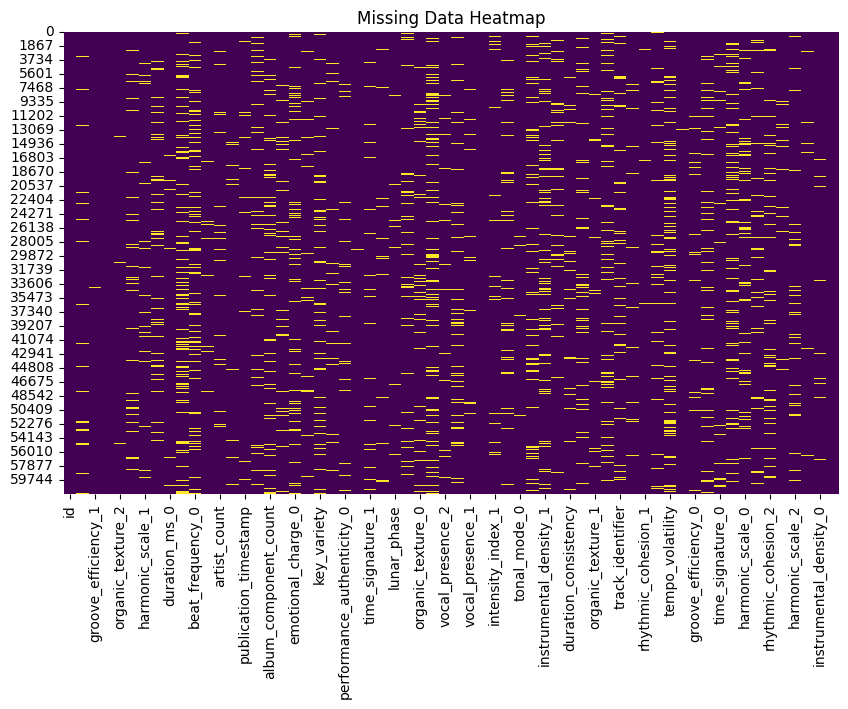

In [10]:
plt.figure(figsize=(10, 6))
sns.heatmap(train_df.isnull(), cmap="viridis", cbar=False)
plt.title("Missing Data Heatmap")
plt.show()

In [11]:
print(f"Duplicate rows: {train_df.duplicated().sum()}")

Duplicate rows: 0


## 04. Handling Data Issues

### Handling Missing Data

In [12]:
def handle_missing_values(train_df, test_df, target_column='target'):

    train_df = train_df.copy()
    test_df = test_df.copy()

    # Identifying numerical and categorical columns
    numerical_cols = list(train_df.select_dtypes(include=["float64", "int64"]).columns)
    categorical_cols = list(train_df.select_dtypes(include=["object"]).columns)

    # Removing the target column from numerical columns
    if target_column in numerical_cols:
        numerical_cols.remove(target_column)

    # Filling missing values in train
    train_df[numerical_cols] = train_df[numerical_cols].fillna(train_df[numerical_cols].mean())
    train_df[categorical_cols] = train_df[categorical_cols].fillna(train_df[categorical_cols].mode().iloc[0])

    # Filling missing values in test (using training stats)
    test_df[numerical_cols] = test_df[numerical_cols].fillna(train_df[numerical_cols].mean())
    test_df[categorical_cols] = test_df[categorical_cols].fillna(train_df[categorical_cols].mode().iloc[0])

    return train_df, test_df

train, test = handle_missing_values(train_df, test_df)

In [13]:
print(train.isnull().sum().sum())  

0


In [14]:
print(test.isnull().sum().sum())  

0


### Encoding Variables & Feature Engineering

In [15]:
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd

# Creating the encoder globally (to reuse for train and test)
ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

def feature_engineering(df, fit_encoder=True):
    df = df.copy()
    
    # Extracting date parts
    df['publication_timestamp'] = pd.to_datetime(df['publication_timestamp'], errors='coerce')
    df['release_year'] = df['publication_timestamp'].dt.year
    df['release_month'] = df['publication_timestamp'].dt.month
    df['release_dayofweek'] = df['publication_timestamp'].dt.dayofweek

    # Dropping original timestamp if not needed
    df = df.drop(columns=['publication_timestamp'])
    
    # Identifying categorical columns
    categorical_cols = df.select_dtypes(include='object').columns.tolist()
    
    # Applying Ordinal Encoding
    if fit_encoder:
        # During training: fit + transform
        df[categorical_cols] = ordinal_encoder.fit_transform(df[categorical_cols])
    else:
        # During testing: just transform
        df[categorical_cols] = ordinal_encoder.transform(df[categorical_cols])
    
    return df
    
train = feature_engineering(train)
test = feature_engineering(test)

### Checking the Correlation Matrix

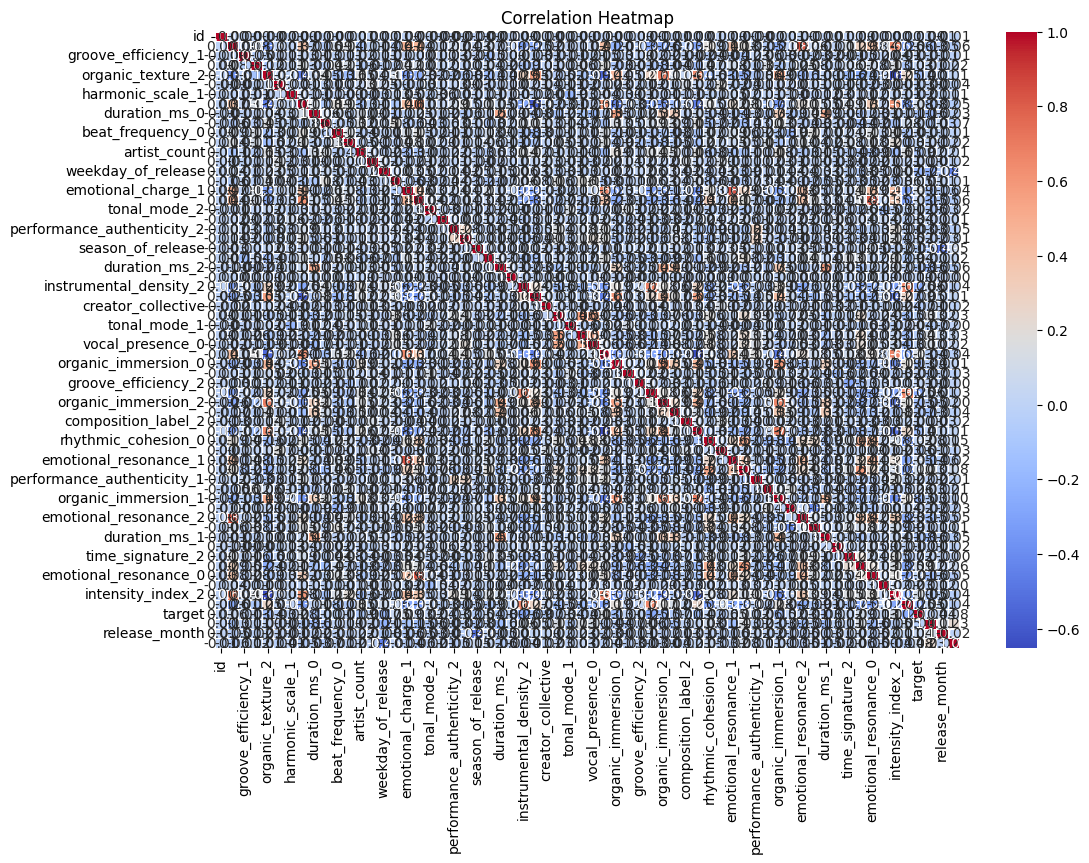

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_correlation_heatmap(df, figsize=(12, 8), annot=True, cmap="coolwarm"):
    plt.figure(figsize=figsize)
    correlation_matrix = df.corr(numeric_only=True)  # Avoiding issues with non-numeric columns
    sns.heatmap(correlation_matrix, annot=annot, cmap=cmap, fmt=".2f", linewidths=0.5)
    plt.title("Correlation Heatmap")
    plt.show()

plot_correlation_heatmap(train)

In [17]:
corr_matrix = train.corr(numeric_only=True)
low_corr_features = corr_matrix['target'][abs(corr_matrix['target']) < 0.01].index
train =train.drop(columns=low_corr_features)

In [18]:
train.head()

,emotional_charge_2,beat_frequency_1,organic_texture_2,composition_label_0,harmonic_scale_1,intensity_index_0,duration_ms_0,artist_count,weekday_of_release,album_component_count,...,time_signature_2,rhythmic_cohesion_2,emotional_resonance_0,harmonic_scale_2,intensity_index_2,instrumental_density_0,target,release_year,release_month,release_dayofweek
0,0.482850,80.018,0.0201,4073.0,1.0,0.789000,154586.0,2.10703,0.0,6.0,...,4.0,0.612252,0.607,7.000000,0.725000,0.000000,74,2021,6,4
1,0.267862,147.966,0.3340,16158.0,6.0,0.715000,46874.0,2.00000,1.0,3.0,...,4.0,0.843000,0.783,4.000000,0.616045,0.043200,2,2019,7,0
2,0.242606,142.980,0.1110,1929.0,4.0,0.604426,264665.0,2.00000,0.0,14.0,...,4.0,0.612252,0.211,10.000000,0.602000,0.000000,35,2014,11,1
3,0.426400,123.063,0.1960,7690.0,5.0,0.685000,209208.0,2.00000,0.0,15.0,...,4.0,0.702000,0.369,5.288894,0.820000,0.000335,70,2015,9,4
4,0.000000,132.722,0.0811,887.0,6.0,0.856000,215346.0,2.00000,0.0,17.0,...,0.0,0.000000,0.631,1.000000,0.022100,0.000000,78,2006,1,6


In [19]:
test = test[train.columns.drop('target', errors='ignore')]

In [20]:
test.head()

,emotional_charge_2,beat_frequency_1,organic_texture_2,composition_label_0,harmonic_scale_1,intensity_index_0,duration_ms_0,artist_count,weekday_of_release,album_component_count,...,duration_ms_1,time_signature_2,rhythmic_cohesion_2,emotional_resonance_0,harmonic_scale_2,intensity_index_2,instrumental_density_0,release_year,release_month,release_dayofweek
0,0.600480,124.008,0.0729,3866.0,1.0,0.763000,23032.0,2.0,0.0,15.000000,...,253987.0,4.0,0.604,0.2050,0.0,0.720,0.165000,2011,10,4
1,0.316976,129.942,0.0105,12154.0,11.0,0.801000,215466.0,2.0,0.0,14.000000,...,267626.0,4.0,0.881,0.2610,1.0,0.496,0.000000,2016,8,4
2,0.461916,83.000,0.2700,11893.0,2.0,0.561000,252261.0,2.0,2.0,15.738549,...,226626.0,4.0,0.555,0.0555,0.0,0.846,0.002760,2011,1,5
3,0.144236,183.991,0.1210,12794.0,2.0,0.604426,198907.0,2.0,5.0,15.000000,...,234286.0,4.0,0.674,0.4040,7.0,0.428,0.000194,2021,9,4
4,0.629832,201.277,0.0610,7402.0,10.0,0.716000,158720.0,2.0,0.0,10.000000,...,188520.0,4.0,0.511,0.9620,10.0,0.652,0.000115,1988,1,4


### Visualizing and Removing Outliers

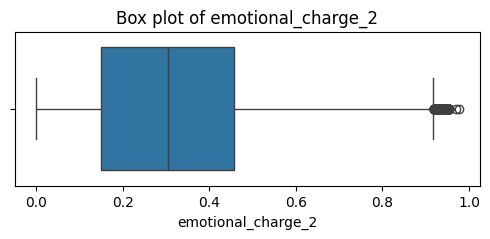

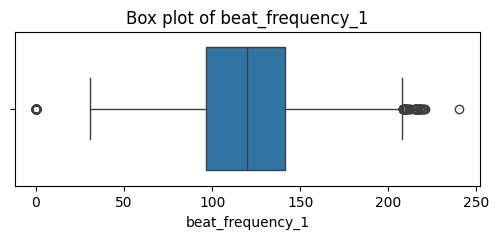

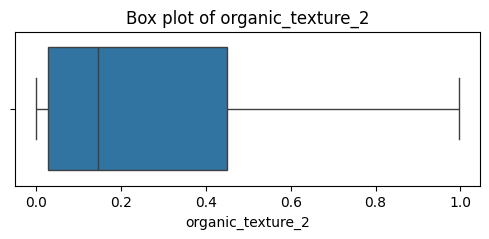

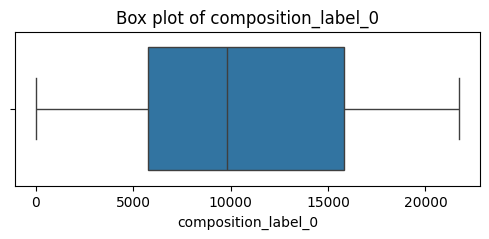

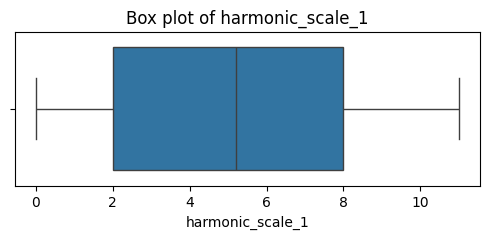

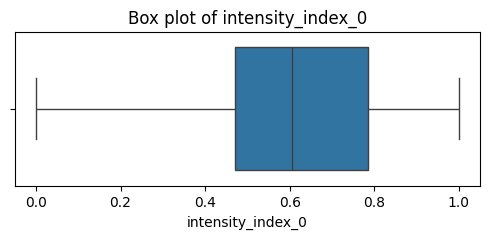

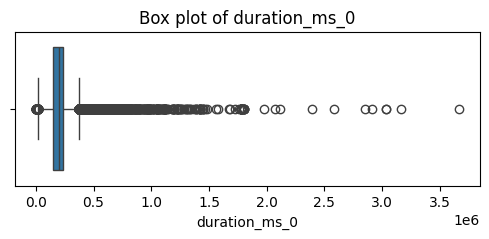

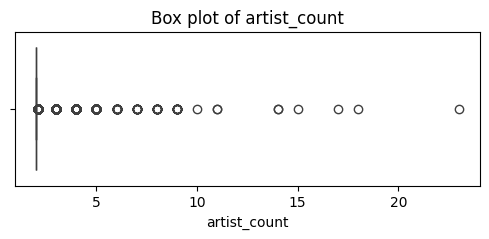

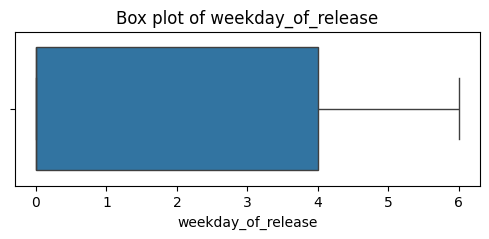

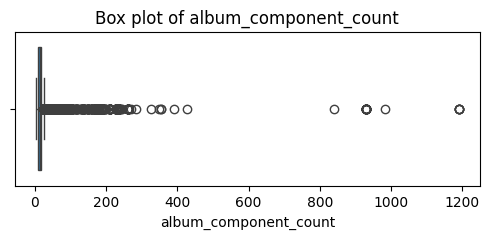

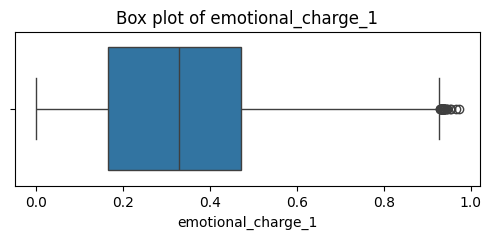

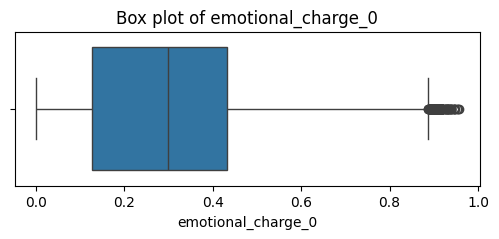

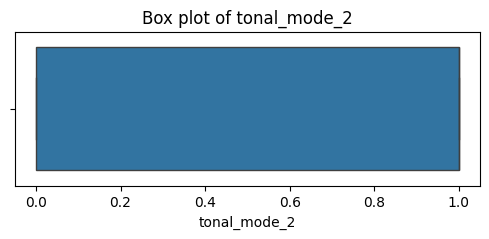

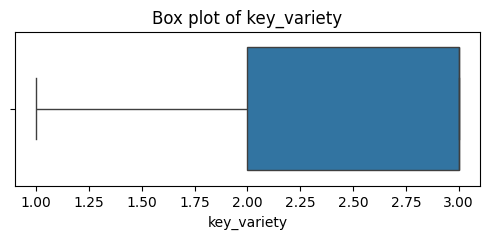

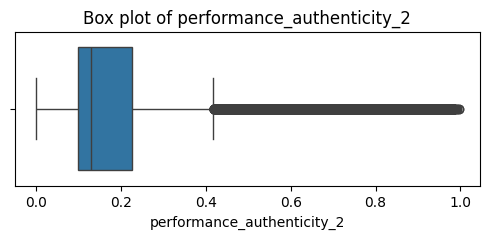

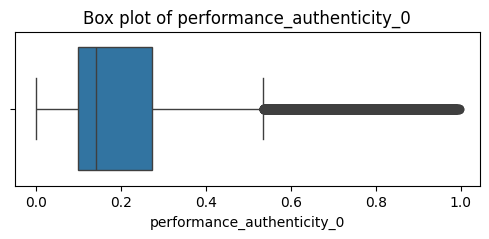

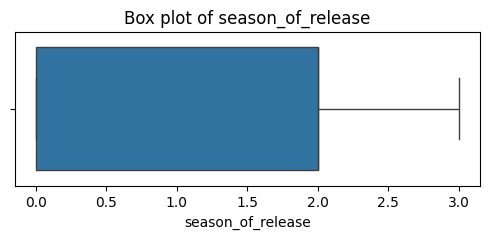

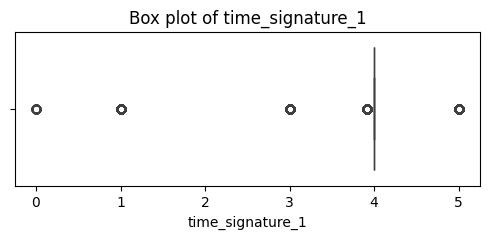

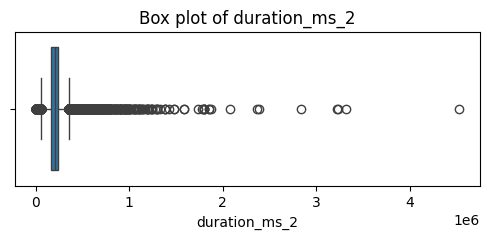

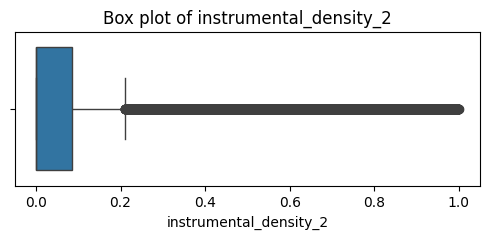

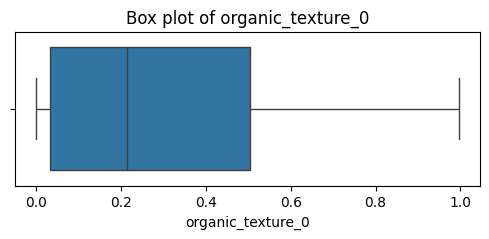

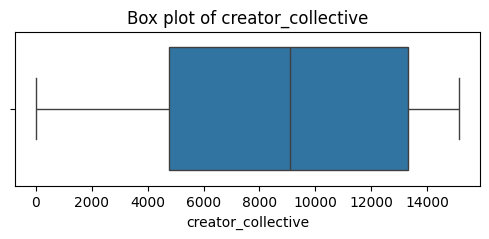

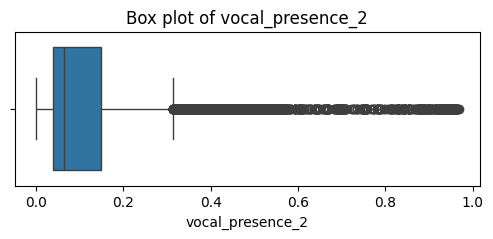

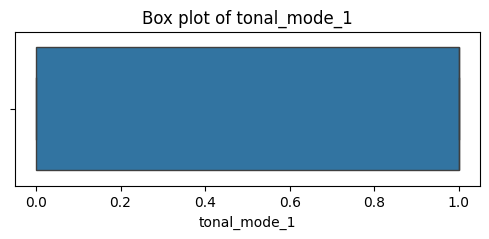

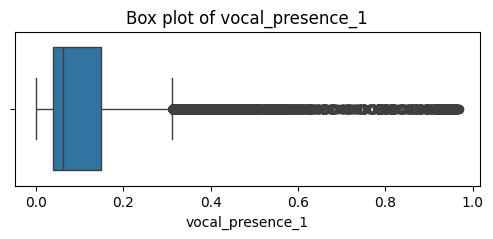

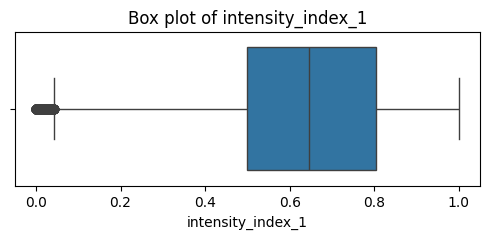

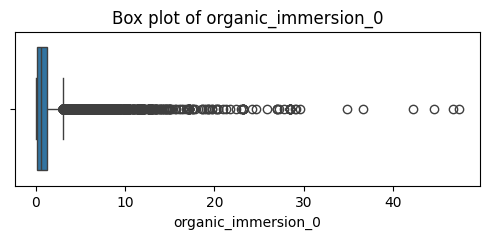

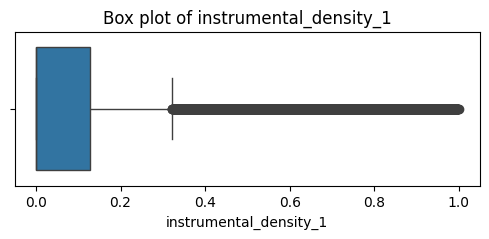

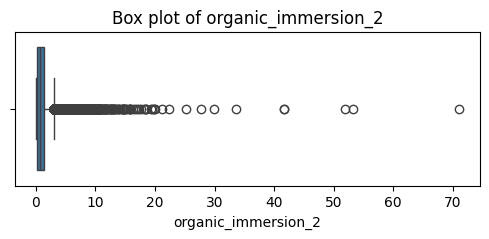

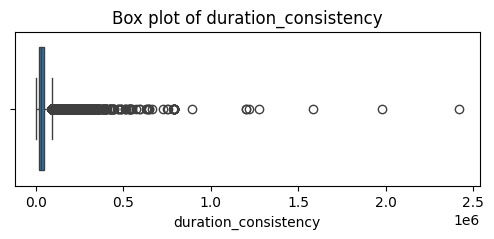

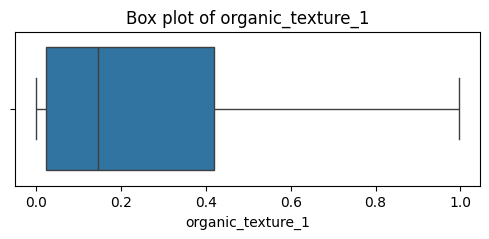

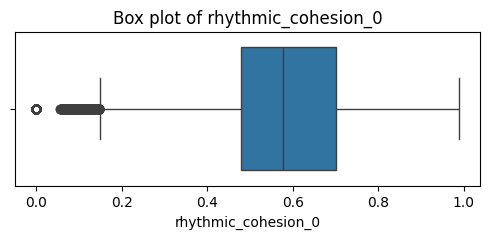

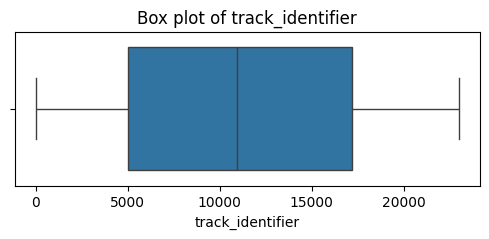

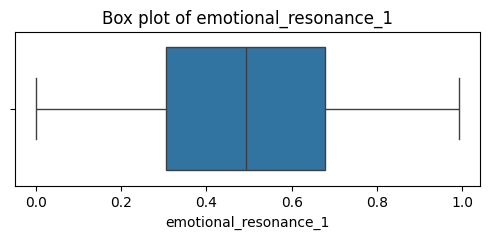

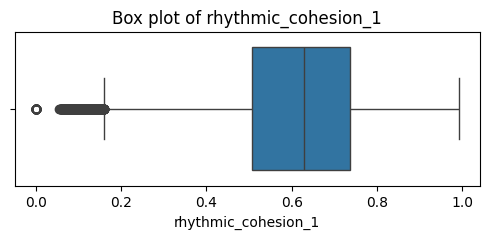

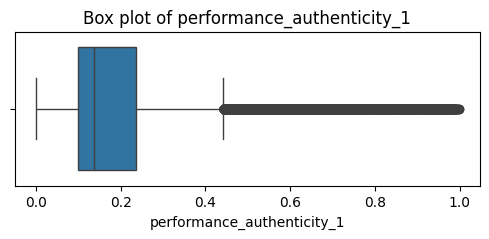

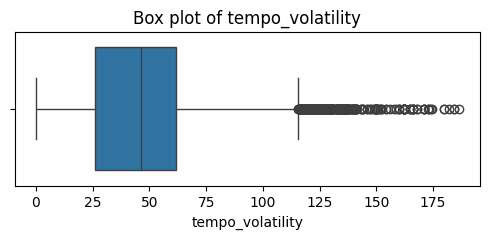

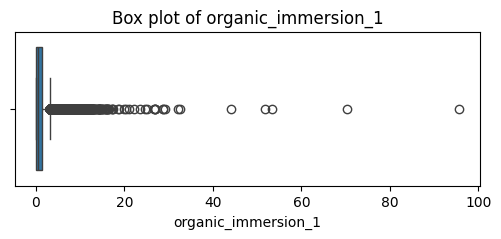

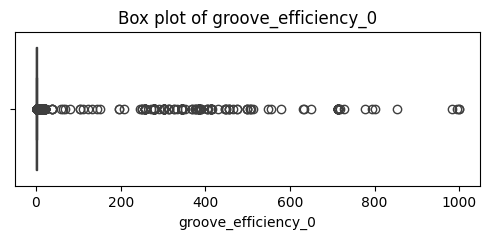

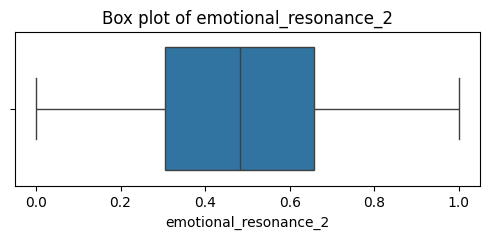

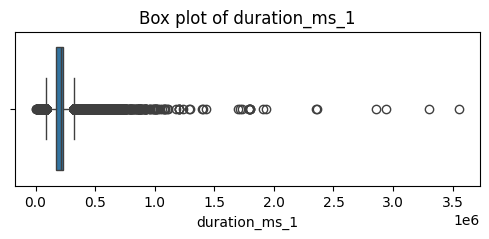

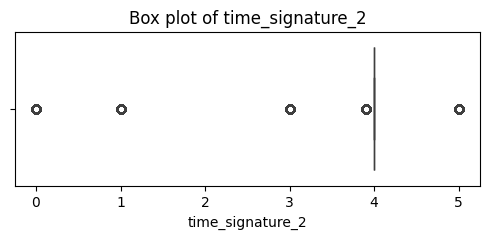

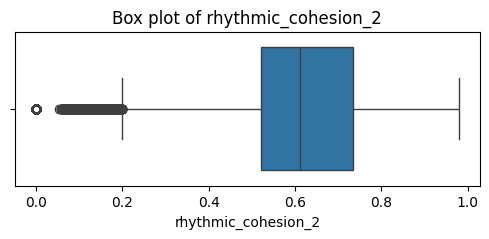

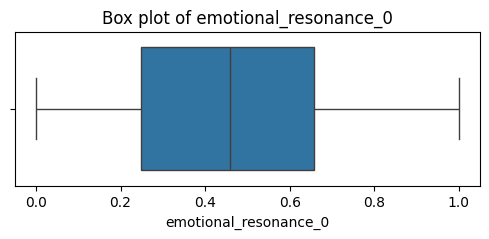

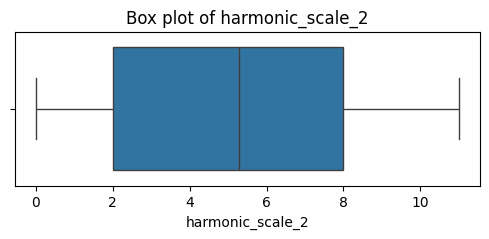

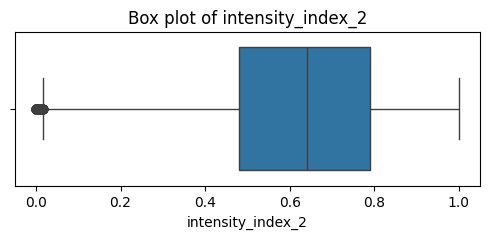

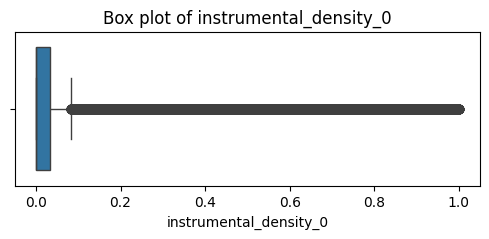

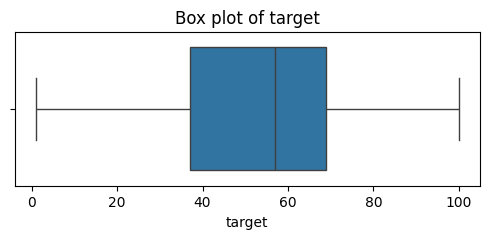

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

def visualize_boxplots(df):
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    for col in numeric_cols:
        plt.figure(figsize=(6, 2))
        sns.boxplot(x=df[col])
        plt.title(f'Box plot of {col}')
        plt.show()

visualize_boxplots(train)

In [22]:
def remove_outliers_iqr(df):
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

train_cleaned = remove_outliers_iqr(train)


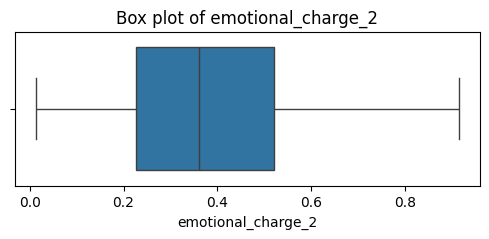

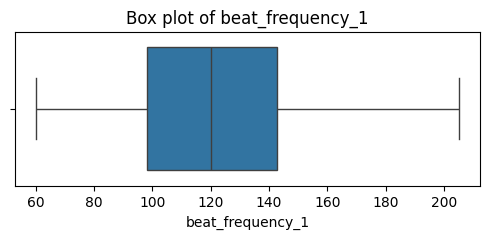

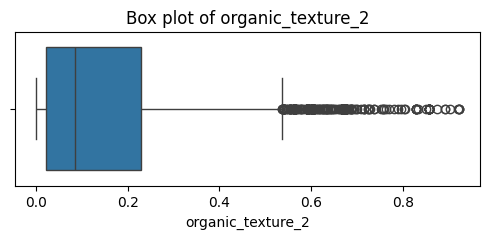

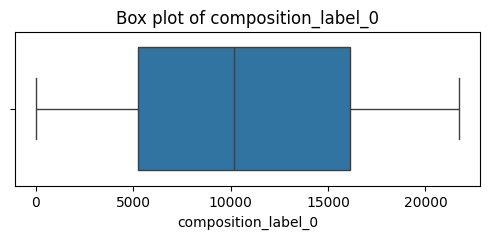

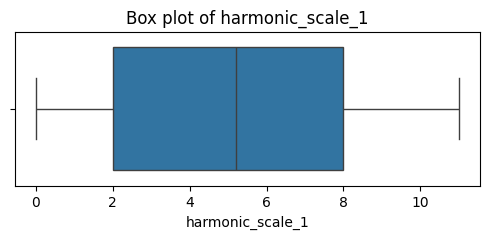

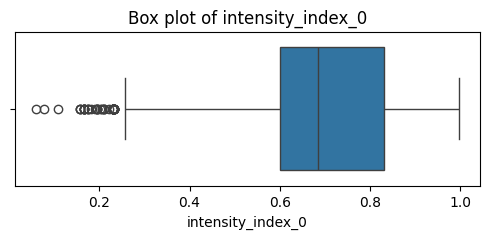

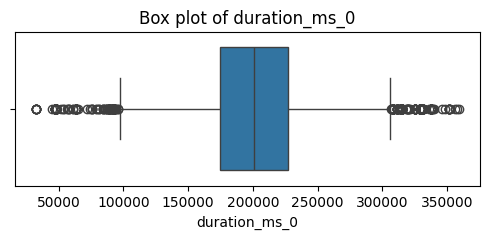

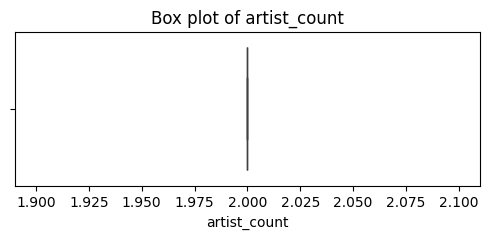

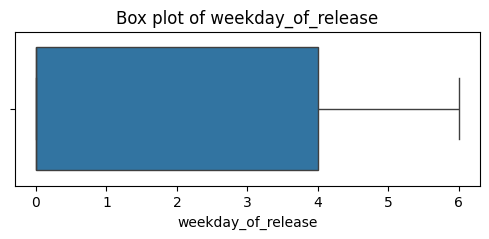

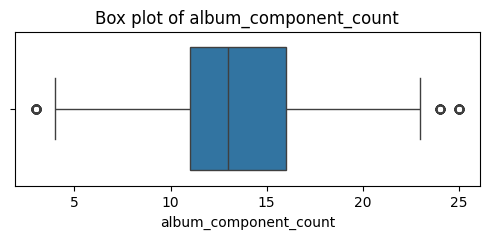

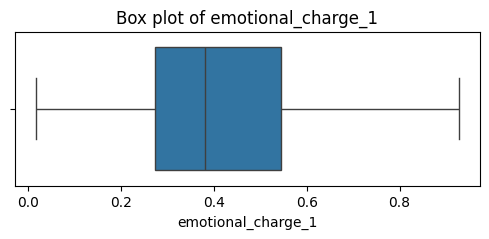

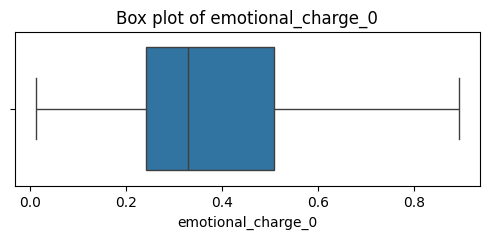

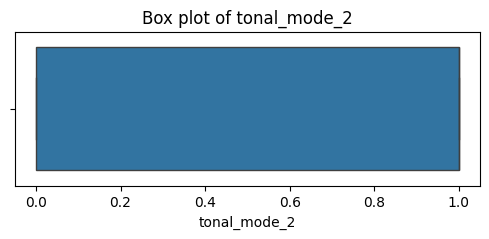

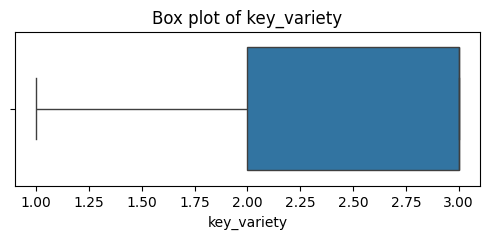

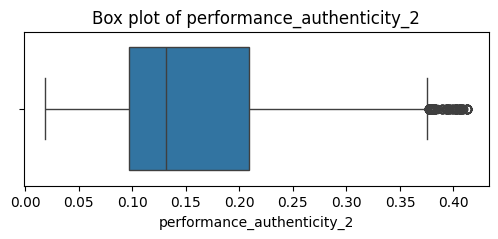

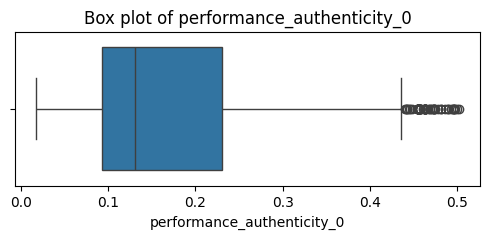

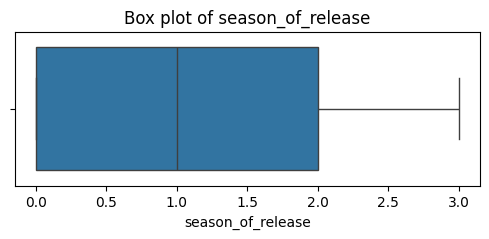

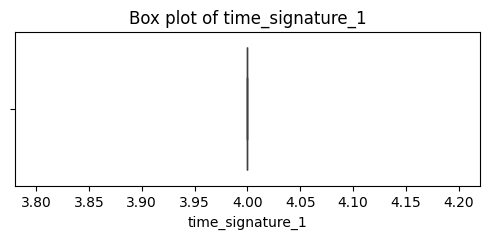

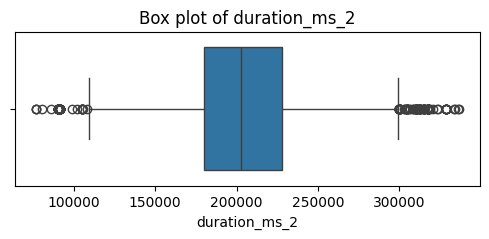

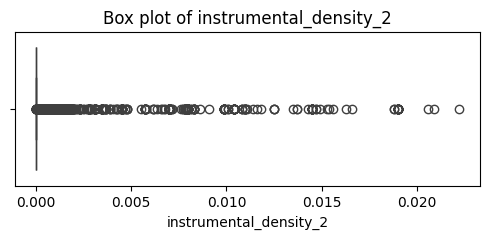

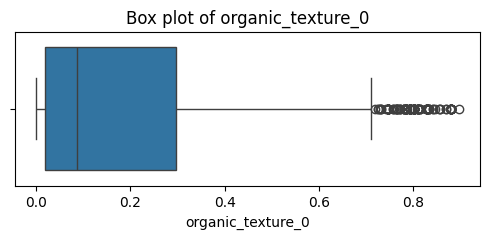

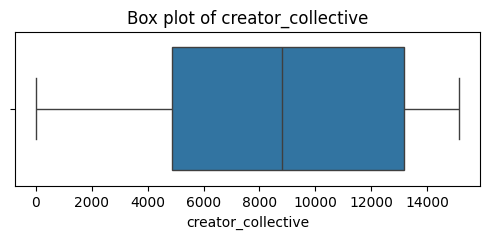

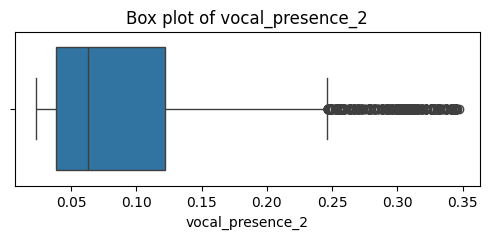

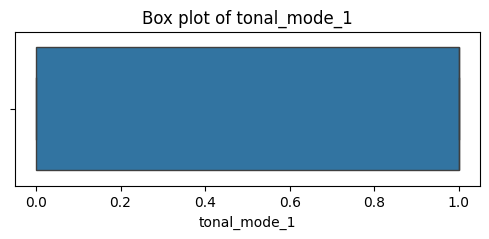

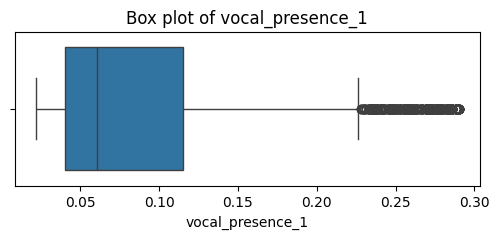

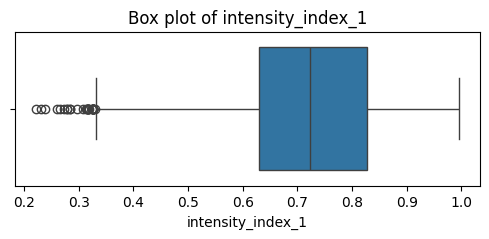

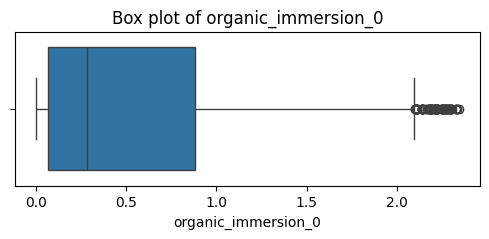

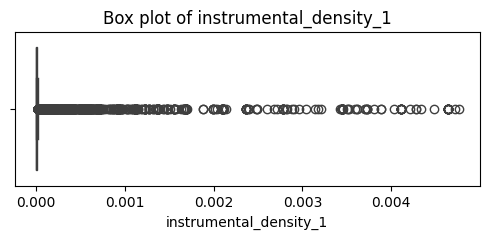

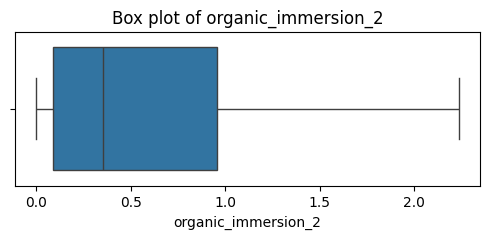

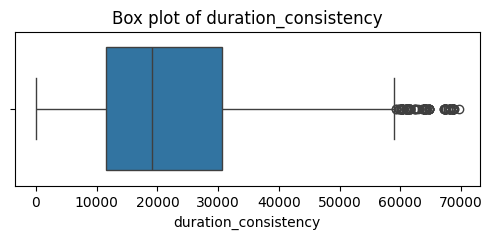

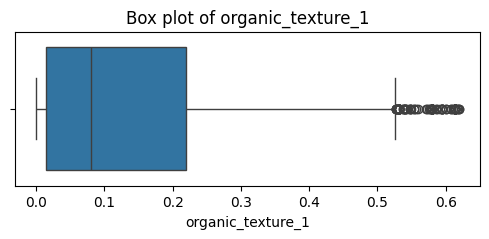

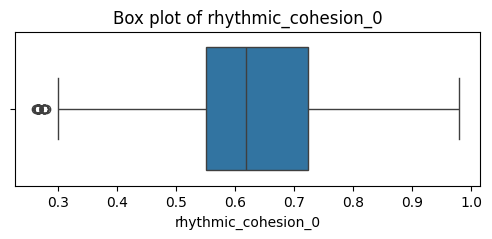

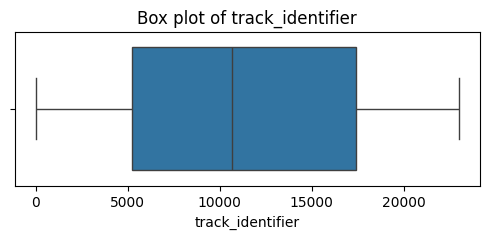

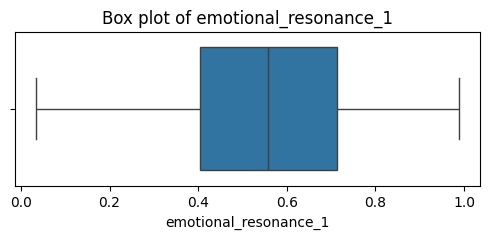

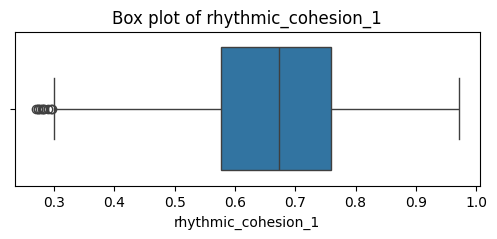

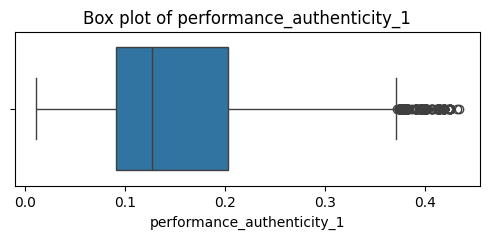

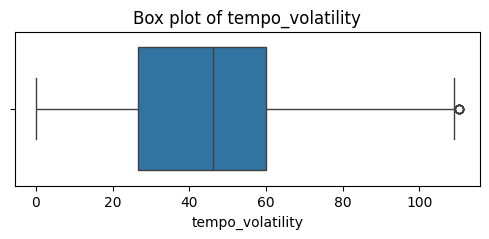

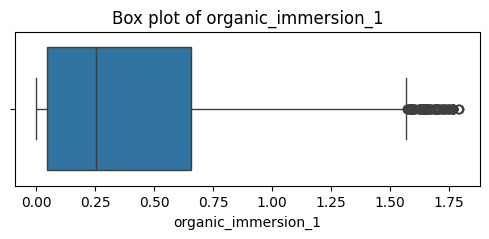

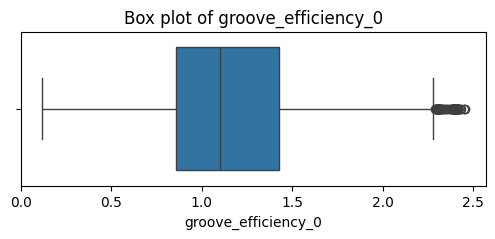

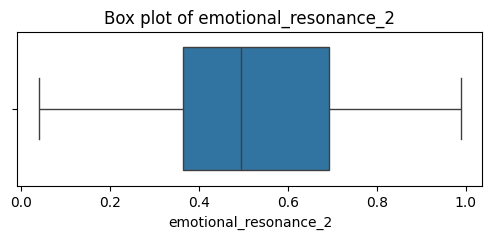

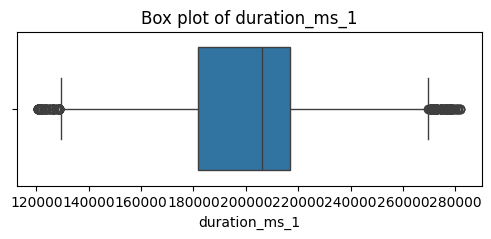

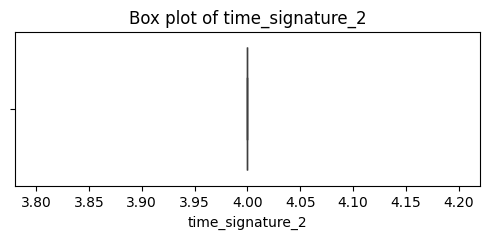

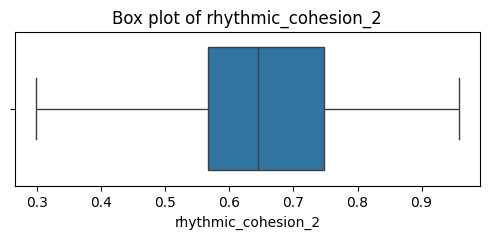

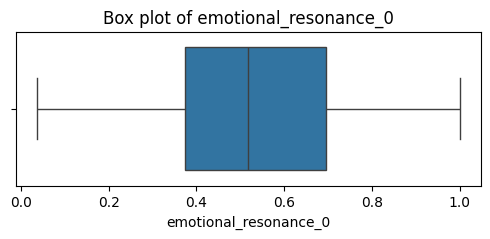

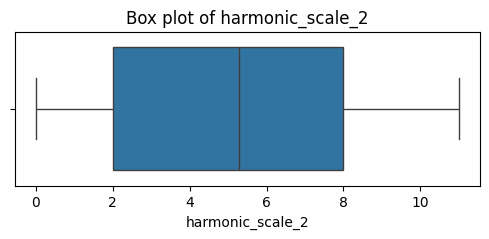

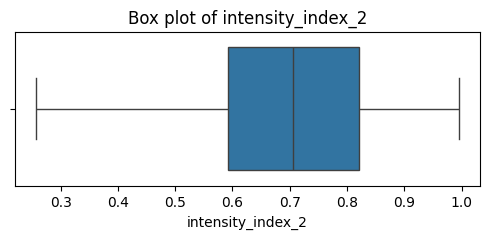

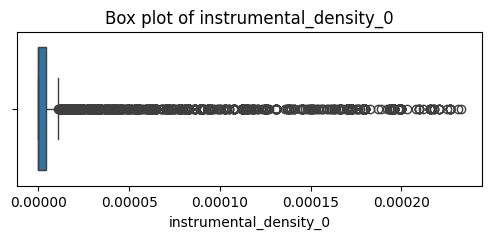

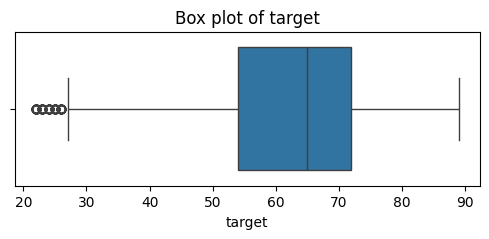

In [23]:
visualize_boxplots(train_cleaned)


In [24]:
print(train_cleaned["target"])

5        44
13       71
19       75
24       51
34       71
         ..
61593    54
61601    25
61602    69
61605    69
61607    88
Name: target, Length: 7895, dtype: int64


## 05. Preparing Features and Target

In [25]:
X = train_cleaned.drop(columns=["target"])
y = train_cleaned["target"]
X_test = test[X.columns]  # Ensuring test set uses the same columns

In [26]:
# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

## 06. Training the Model

In [27]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

## 07. Evaluating the Model & Making Predictions

In [28]:
y_pred = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print("Validation RMSE:", rmse)

Validation RMSE: 7.5686834954527065


In [29]:
test_predictions = model.predict(X_test)

### Preparing the Submission

In [30]:
submission = sample_submission.copy()
submission["target"] = test_predictions

In [31]:
submission.head()

,id,target
0,25174,56.73
1,38453,66.28
2,29013,54.92
3,57463,71.73
4,51264,52.02


In [32]:
submission.to_csv("submission101.csv", index=False)
print("Submission file saved as 'submission.csv'")

Submission file saved as 'submission.csv'
